# **WEEK-6 DFeature Engineering and Market Metrics**

goal :
- Feature Engineering

### Set Up

In [2]:
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
import os

DATA_DIR = Path("/Users/kmaxx/Desktop/IDX-da/idx_data")

sold_df = pd.read_csv(DATA_DIR / "cleaned_sold.csv", low_memory= False)
listing_df = pd.read_csv(DATA_DIR / "cleaned_listing.csv", low_memory= False)

In [3]:
sold_df.shape

(447491, 57)

In [4]:
listing_df.shape

(613615, 54)

### Feature Engineering

In [5]:
date_columns = [
    "CloseDate",
    "PurchaseContractDate",
    "ListingContractDate"
]

numeric_columns = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "DaysOnMarket"
]

for df in [sold_df, listing_df]:
    existing_dates = [col for col in date_columns if col in df.columns]
    existing_numeric = [col for col in numeric_columns if col in df.columns]

    df[existing_dates] = df[existing_dates].apply(pd.to_datetime, errors="coerce")
    df[existing_numeric] = df[existing_numeric].apply(pd.to_numeric, errors="coerce")

In [6]:
# Close price compared with original list price
sold_df["PriceRatio"] = sold_df["ClosePrice"] / sold_df["OriginalListPrice"]

# Price per square foot
sold_df["PricePerSqFt"] = sold_df["ClosePrice"] / sold_df["LivingArea"]

# Date-based variables
sold_df["Year"] = sold_df["CloseDate"].dt.year
sold_df["Month"] = sold_df["CloseDate"].dt.month
sold_df["YrMo"] = sold_df["CloseDate"].dt.to_period("M")

# Days from listing to accepted contract
sold_df["ListingToContractDays"] = (sold_df["PurchaseContractDate"] - sold_df["ListingContractDate"]).dt.days

# Days from accepted contract to closing
sold_df["ContractToCloseDays"] = (sold_df["CloseDate"] - sold_df["PurchaseContractDate"]).dt.days

In [7]:
metric_columns = [
    "PriceRatio",
    "PricePerSqFt",
    "ListingToContractDays",
    "ContractToCloseDays"
]

missing_summary = sold_df[metric_columns].isna().sum().to_frame("missing_count")
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(sold_df) * 100).round(2)

display(missing_summary)

,missing_count,missing_pct
PriceRatio,824,0.18
PricePerSqFt,0,0.00
ListingToContractDays,198,0.04
ContractToCloseDays,197,0.04


In [8]:
sold_df.get(metric_columns).head()

,PriceRatio,PricePerSqFt,ListingToContractDays,ContractToCloseDays
0,0.943396,145.095763,358.0,572.0
1,0.964336,181.050328,116.0,968.0
2,1.208333,422.494172,140.0,42.0
3,1.000000,375.000000,48.0,9.0
4,1.043478,347.624565,0.0,1.0


### Add School District Mapping

In [9]:
import geopandas as gpd
DATA_DIR = Path("/Users/kmaxx/Desktop/IDX-da/idx_data")

districts = gpd.read_file(
    DATA_DIR / "DistrictAreas2526.geojson"
)

print(districts.shape)
print(districts.crs)
print(districts.columns.tolist())

(936, 51)
EPSG:3857
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'LocaleCode', 'LocaleDesc', 'geometry']


#### District Summary

In [10]:
district_type_summary = districts["DistrictType"].value_counts(dropna=False).rename_axis("DistrictType").reset_index(name="Count")

district_type_summary["Percentage"] = (district_type_summary["Count"] / district_type_summary["Count"].sum() * 100).round(2)

display(district_type_summary)

,DistrictType,Count,Percentage
0,Elementary,515,55.02
1,Unified,345,36.86
2,High,76,8.12


#### Filtering to Unified
visualize district and geometry

In [11]:
unified_districts = districts.loc[districts["DistrictType"].astype("string").str.strip().str.casefold().eq("unified")].copy()
unified_districts = unified_districts[["DistrictName", "geometry"]].copy()

print("Unified districts:", len(unified_districts))
unified_districts.head()

Unified districts: 345


,DistrictName,geometry
0,Alameda Unified,"MULTIPOLYGON (((-13606222.82 4540862.699, -136..."
1,Albany City Unified,"POLYGON ((-13612893.866 4565099.707, -13612896..."
2,Berkeley Unified,"POLYGON ((-13609482.48 4565074.597, -13609483...."
3,Castro Valley Unified,"MULTIPOLYGON (((-13582508.535 4529067.071, -13..."
4,Emery Unified,"POLYGON ((-13613999.038 4555592.769, -13614126..."


#### Sold df
Convert each property’s Latitude and Longitude into a geographic point

In [12]:
coordinate_columns = [
    "Latitude",
    "Longitude"
]

sold_df[coordinate_columns] = sold_df[coordinate_columns].apply(pd.to_numeric, errors="coerce")

valid_coordinates = sold_df[coordinate_columns].notna().all(axis=1)

sold_points = gpd.GeoDataFrame(
    sold_df.loc[valid_coordinates].copy(),
    geometry=gpd.points_from_xy(
        sold_df.loc[valid_coordinates, "Longitude"],
        sold_df.loc[valid_coordinates, "Latitude"]
    ),
    crs="EPSG:4326"
)

sold_points[coordinate_columns + ["geometry"]].head()

,Latitude,Longitude,geometry
0,36.783028,-119.768450,POINT (-119.76845 36.78303)
1,33.605045,-116.473489,POINT (-116.47349 33.60504)
2,32.554950,-117.049710,POINT (-117.04971 32.55495)
3,32.742623,-116.988226,POINT (-116.98823 32.74262)
4,37.709881,-122.415263,POINT (-122.41526 37.70988)


#### Spatial join

In [13]:
join_columns = [
    "DistrictName",
    "geometry"
]

preview_columns = [
    "Latitude",
    "Longitude",
    "DistrictName"
]

# Match the coordinate reference systems
sold_points = sold_points.to_crs(unified_districts.crs)

# Match each property point to its unified school district
sold_joined = gpd.sjoin(sold_points,unified_districts[join_columns],how="left",predicate="within")

sold_joined[preview_columns].head()

,Latitude,Longitude,DistrictName
0,36.783028,-119.768450,Fresno Unified
1,33.605045,-116.473489,Palm Springs Unified
2,32.554950,-117.049710,NaN
3,32.742623,-116.988226,NaN
4,37.709881,-122.415263,San Francisco Unified


In [14]:
# Create one district result for each original row
district_lookup = sold_joined.groupby(level=0)["DistrictName"].first()

# Add the district name to the original sold dataset
sold_df["DistrictName"] = sold_df.index.map(district_lookup)

preview_columns = [
    "UnparsedAddress",
    "City",
    "Latitude",
    "Longitude",
    "DistrictName"
]

sold_df[preview_columns].head(10)

,UnparsedAddress,City,Latitude,Longitude,DistrictName
0,3533 Virginia Lane N,Fresno,36.783028,-119.768450,Fresno Unified
1,68252 Materhorn,Pinyon Pines,33.605045,-116.473489,Palm Springs Unified
2,2378 Smythe Avenue,San Ysidro,32.554950,-117.049710,None
3,3457 Kenora Dr,Spring Valley,32.742623,-116.988226,None
4,312 Argonaut Ave,San Francisco,37.709881,-122.415263,San Francisco Unified
5,846 Crossbrook Ct,Moraga,37.841644,-122.128606,None
6,817 Chestnut Avenue,Brea,33.909031,-117.908176,Brea-Olinda Unified
7,13000 Requlo Place,San Diego,32.961495,-117.185947,None
8,3156 Cyrus Avenue,San Jose,37.266550,-121.915581,None
9,1734 Wolfe Drive,San Mateo,37.556318,-122.303639,None


In [15]:
print(
    "Properties without a unified district:",
    sold_df["DistrictName"].isna().sum()
)

print(
    "Missing percentage:",
    round(sold_df["DistrictName"].isna().mean() * 100, 2),
    "%"
)

Properties without a unified district: 112525
Missing percentage: 25.15 %


#### Listing_df

In [24]:
coordinate_columns = [
    "Latitude",
    "Longitude"
]

listing_df[coordinate_columns] = listing_df[coordinate_columns].apply(pd.to_numeric, errors="coerce")

valid_coordinates = listing_df[coordinate_columns].notna().all(axis=1)

listing_points = gpd.GeoDataFrame(
    listing_df.loc[valid_coordinates].copy(),
    geometry=gpd.points_from_xy(
        listing_df.loc[valid_coordinates, "Longitude"],
        listing_df.loc[valid_coordinates, "Latitude"]
    ),
    crs="EPSG:4326"
)

listing_points = listing_points.to_crs(unified_districts.crs)

listing_joined = gpd.sjoin(
    listing_points,
    unified_districts[
        [
            "DistrictName",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

district_lookup = listing_joined.groupby(level=0)["DistrictName"].first()
listing_df["DistrictName"] = listing_df.index.map(district_lookup)

In [26]:
preview_columns = [
    "UnparsedAddress",
    "City",
    "Latitude",
    "Longitude",
    "DistrictName"
]

listing_df[preview_columns].head(10)

,UnparsedAddress,City,Latitude,Longitude,DistrictName
0,16882 Canyon Lane,Huntington Beach,NaN,NaN,NaN
1,8720 S 4th Avenue,Inglewood,NaN,NaN,NaN
2,505 E Molino Road,Palm Springs,33.858559,-116.542169,Palm Springs Unified
3,1736 N Mcdivitt Avenue,Compton,NaN,NaN,NaN
4,13130 Mercer Street,Pacoima,NaN,NaN,NaN
5,1252 Apple Avenue,Wrightwood,NaN,NaN,NaN
6,2858 Chios Road,Costa Mesa,NaN,NaN,NaN
7,1826 S 4th Street,El Centro,32.777540,-115.553772,None
8,28914 Gateway Ct.,Saugus,NaN,NaN,NaN
9,2890 51st street,San Diego,NaN,NaN,NaN


In [27]:
print("Matched:", listing_df["DistrictName"].notna().sum())
print("No district match:", listing_df["DistrictName"].isna().sum())

Matched: 410347
No district match: 203268


### Segment Analysis

In [16]:
import pandas as pd

def create_segment_summary(df, group_columns):
    required_metrics = [
        "ClosePrice",
        "PriceRatio",
        "PricePerSqFt",
        "DaysOnMarket",
        "ListingToContractDays",
        "ContractToCloseDays"
    ]

    data = df.copy()

    for col in required_metrics:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    count_column = "ListingKey" if "ListingKey" in data.columns else "ClosePrice"

    summary = data.groupby(
        group_columns,
        dropna=False,
        observed=True
    ).agg(
        ListingCount=(count_column, "nunique"),
        AverageClosePrice=("ClosePrice", "mean"),
        AveragePriceRatio=("PriceRatio", "mean"),
        AveragePricePerSqFt=("PricePerSqFt", "mean"),
        AverageDaysOnMarket=("DaysOnMarket", "mean"),
        AverageListingToContractDays=("ListingToContractDays", "mean"),
        AverageContractToCloseDays=("ContractToCloseDays", "mean")
    ).reset_index()

    mean_columns = [
        col for col in summary.select_dtypes("number").columns
        if col != "ListingCount"
    ]

    summary[mean_columns] = summary[mean_columns].round(2)

    return summary.sort_values(["ListingCount", "AverageClosePrice"], ascending=[False, False]).reset_index(drop=True)

#### 1. School district and property subtype

In [17]:
district_property_summary = create_segment_summary(sold_df,["DistrictName","PropertySubType"])

display(district_property_summary.head(10))

,DistrictName,PropertySubType,ListingCount,AverageClosePrice,AveragePriceRatio,AveragePricePerSqFt,AverageDaysOnMarket,AverageListingToContractDays,AverageContractToCloseDays
0,NaN,SingleFamilyResidence,85653,1305447.60,1.60,662.65,31.99,39.28,31.60
1,Los Angeles Unified,SingleFamilyResidence,32369,1640898.64,1.81,762.72,35.56,41.86,34.24
2,NaN,Condominium,16560,830996.01,58.66,696.06,37.93,42.23,33.19
3,Los Angeles Unified,Condominium,9345,920131.97,1.45,658.90,48.51,53.35,32.07
4,San Diego Unified,SingleFamilyResidence,8764,1635893.14,1.20,901.43,23.87,31.59,27.05
5,NaN,Townhouse,8040,1051485.26,1.15,707.28,30.25,35.81,31.22
6,Desert Sands Unified,SingleFamilyResidence,6117,973813.05,inf,379.84,66.19,79.80,18.25
7,Capistrano Unified,SingleFamilyResidence,6045,2068083.85,0.99,806.33,33.92,46.34,29.62
8,San Diego Unified,Condominium,5919,978839.84,1.29,943.48,34.33,39.98,27.40
9,Palm Springs Unified,SingleFamilyResidence,5225,980207.10,1.71,427.07,63.55,71.24,26.17


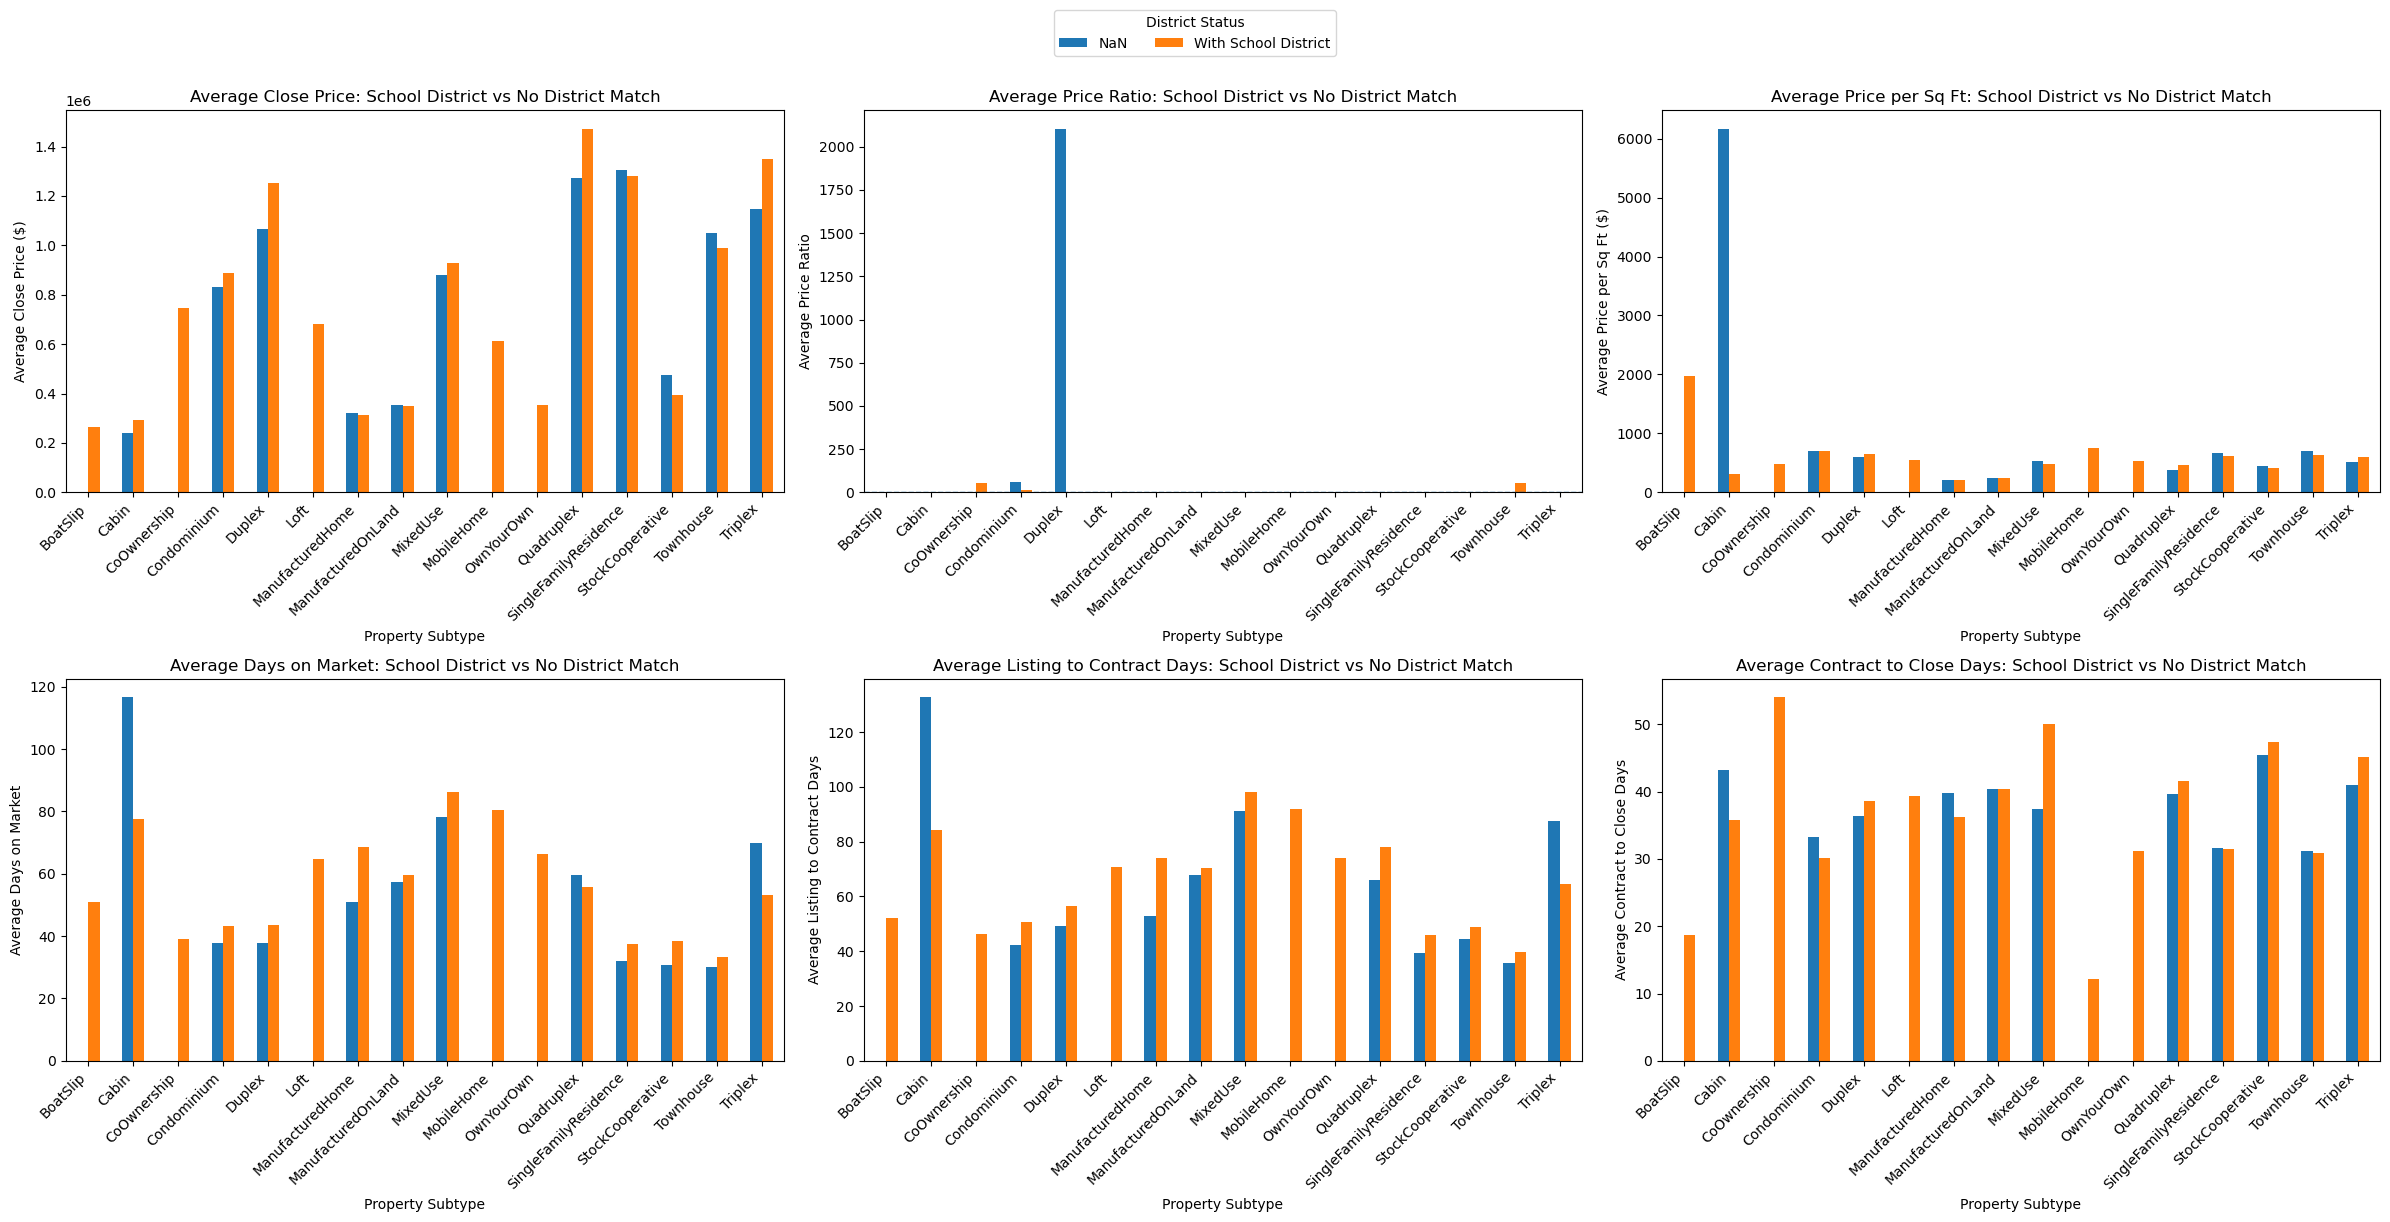

In [29]:
import matplotlib.pyplot as plt

minimum_listings = 10

plot_data = district_status_summary.loc[
    district_status_summary["PropertySubType"].notna()
    & (district_status_summary["ListingCount"] >= minimum_listings)
].copy()

metric_columns = [
    "AverageClosePrice",
    "AveragePriceRatio",
    "AveragePricePerSqFt",
    "AverageDaysOnMarket",
    "AverageListingToContractDays",
    "AverageContractToCloseDays"
]

metric_titles = [
    "Average Close Price",
    "Average Price Ratio",
    "Average Price per Sq Ft",
    "Average Days on Market",
    "Average Listing to Contract Days",
    "Average Contract to Close Days"
]

y_labels = [
    "Average Close Price ($)",
    "Average Price Ratio",
    "Average Price per Sq Ft ($)",
    "Average Days on Market",
    "Average Listing to Contract Days",
    "Average Contract to Close Days"
]

fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

for ax, metric, title, y_label in zip(axes, metric_columns, metric_titles, y_labels):
    pivot = plot_data.pivot(
        index="PropertySubType",
        columns="DistrictStatus",
        values=metric
    )

    pivot.plot(kind="bar", ax=ax)

    if metric == "AveragePriceRatio":
        ax.axhline(1, linestyle="--", linewidth=1)

    ax.set_title(f"{title}: School District vs No District Match")
    ax.set_xlabel("Property Subtype")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=45)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(
    handles,
    labels,
    title="District Status",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [31]:
county_mls_summary = create_segment_summary(sold_df,["CountyOrParish","MLSAreaMajor"])

display(county_mls_summary.head(10))

,CountyOrParish,MLSAreaMajor,ListingCount,AverageClosePrice,AveragePriceRatio,AveragePricePerSqFt,AverageDaysOnMarket,AverageListingToContractDays,AverageContractToCloseDays
0,Riverside,SRCAR - Southwest Riverside County,21840,639018.38,67.70,321.52,41.45,53.27,37.05
1,Contra Costa,NaN,19803,1140698.57,1.06,585.84,28.38,29.69,25.83
2,Alameda,NaN,19279,1316679.70,1.25,773.13,25.70,26.73,25.25
3,Santa Clara,699 - Not Defined,18197,1949839.35,1.04,1076.07,21.50,21.53,25.30
4,San Mateo,699 - Not Defined,7297,2243866.07,1.03,1126.34,27.69,22.22,29.03
5,Riverside,252 - Riverside,5664,712573.69,1.02,389.94,37.93,47.99,36.56
6,Butte,NaN,4398,434959.55,1.20,261.95,52.01,59.90,34.48
7,Monterey,699 - Not Defined,4157,1409039.66,0.96,753.09,45.29,47.26,30.94
8,Riverside,248 - Corona,3600,800724.82,286.00,403.69,39.40,50.09,35.10
9,Los Angeles,LAC - Lancaster,3310,489745.99,1.59,277.64,41.41,48.86,38.53


#### 3. Listing office and buyer office

In [32]:
office_competition_summary = create_segment_summary(sold_df,["ListOfficeName","BuyerOfficeName"])

display(office_competition_summary.head(10))

,ListOfficeName,BuyerOfficeName,ListingCount,AverageClosePrice,AveragePriceRatio,AveragePricePerSqFt,AverageDaysOnMarket,AverageListingToContractDays,AverageContractToCloseDays
0,Compass,Compass,8118,2132292.95,1.13,948.38,29.26,34.53,26.26
1,Coldwell Banker Realty,Coldwell Banker Realty,3815,2044466.48,1.25,983.97,33.14,41.87,26.81
2,Coldwell Banker Realty,Compass,1737,2019175.69,1.00,931.30,31.20,35.38,26.81
3,Keller Williams Realty,Keller Williams Realty,1499,1089823.99,1.01,571.51,29.88,38.52,32.30
4,Compass,Coldwell Banker Realty,1444,2192541.71,1.61,964.73,30.80,36.42,24.99
5,First Team Real Estate,First Team Real Estate,1215,1243767.12,1.80,669.14,24.20,40.62,29.31
6,Intero Real Estate Services,Intero Real Estate Services,908,1750480.96,1.03,976.73,22.09,21.69,26.95
7,Compass,NaN,904,1775543.86,1.04,963.28,26.94,-13.83,64.98
8,Berkshire Hathaway HomeServices California Pro...,Berkshire Hathaway HomeServices California Pro...,859,1688998.73,0.97,749.83,40.46,47.72,30.80
9,Equity Union,Equity Union,850,1059474.96,2118.61,494.58,38.83,46.95,24.67


### Export

In [28]:
sold_df.to_csv(DATA_DIR / "featured_sold.csv", index = False)
listing_df.to_csv(DATA_DIR / "featured_listing.csv", index = False)